# Time Series Forecasting Lab Implementation

This notebook implements the lab requirements for BBT4206 Time Series Analysis and Forecasting.

## Lab Requirements:
- Use different stock data (not from existing notebooks)
- Implement baseline, intermediate, and advanced forecasting levels
- Forecast next 63 business days
- Save results as CSV files for Power BI import


## Step 1: Import Required Libraries

In [1]:
# For file and system operations
import urllib.request
import os

# For data download
import yfinance as yf

# For time series analysis
import pandas as pd
import numpy as np
import re
import pandas_datareader as pdr
import datetime as dt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression

# For data visualization
import matplotlib.pyplot as plt
import mplfinance as mpf

# For time series forecasting
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

## For time series forecasting with LSTM
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# For candlestick pattern recognition
import talib
from talib import abstract

# For sentiment analysis
import requests
from bs4 import BeautifulSoup
import textblob
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# For additional technical analysis
import ta
from ta import add_all_ta_features

# For web scraping and news analysis
import feedparser
from urllib.parse import urlencode
import json

# For suppressing warnings
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Download required NLTK data
try:
    nltk.download('vader_lexicon', quiet=True)
    nltk.download('punkt', quiet=True)
except:
    print("Note: NLTK data download may require internet connection")

# Ensures that matplotlib plots are displayed directly within the notebook
%matplotlib inline


ModuleNotFoundError: No module named 'pandas_datareader'

## Step 2: Download New Stock Data

Using Apple Inc. (AAPL) stock data.


In [ ]:
# Download Apple Inc. stock data
ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2024-12-31"

# Download data
stock_data = yf.download(ticker, start=start_date, end=end_date)

print(f"Downloaded {len(stock_data)} days of {ticker} stock data")
print(f"Date range: {stock_data.index[0].strftime('%Y-%m-%d')} to {stock_data.index[-1].strftime('%Y-%m-%d')}")
print(f"Columns: {list(stock_data.columns)}")

# Display first few rows
display(stock_data.head())
display(stock_data.tail())


[*********************100%***********************]  1 of 1 completed

Downloaded 1257 days of AAPL stock data
Date range: 2020-01-02 to 2024-12-30
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.538536,72.598914,71.292326,71.545912,135480400
2020-01-03,71.833282,72.594048,71.608677,71.765659,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065178,72.671371,71.845400,72.415368,108872000
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,254.367004,254.745650,252.553435,253.868773,40858800
2024-12-24,257.286682,257.296626,254.386957,254.586262,23234700
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100
2024-12-27,254.685867,257.784882,252.164818,256.917934,42355300
2024-12-30,251.307877,252.603281,249.863009,251.337769,35557500


## Step 3: Data Preprocessing


In [ ]:
# Clean and prepare the data
data = stock_data.copy()

# yfinance returns multi-level columns, so we need to flatten them
if isinstance(data.columns, pd.MultiIndex):
    # Flatten multi-level columns by taking the first level
    data.columns = data.columns.get_level_values(0)

print(f"Columns after flattening: {list(data.columns)}")

# Ensure we have the required columns
required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in required_columns:
    if col not in data.columns:
        print(f"Warning: {col} column not found")

# Drop any rows with missing values in OHLC
ohlc_cols = ['Open', 'High', 'Low', 'Close']
data = data.dropna(subset=ohlc_cols)

# Ensure data is sorted by date
data = data.sort_index()

print(f"Final dataset shape: {data.shape}")
print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")

# Display summary statistics
display(data.describe())


Columns after flattening: ['Close', 'High', 'Low', 'Open', 'Volume']
Final dataset shape: (1257, 5)
Date range: 2020-01-02 to 2024-12-30


Price,Close,High,Low,Open,Volume
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.728301,153.253333,150.026017,151.571824,9.061168e+07
std,41.896383,42.035035,41.671140,41.835806,5.324605e+07
min,54.316940,55.316759,51.470005,55.215083,2.323470e+07
25%,126.607025,127.694610,124.586260,126.080066,5.546960e+07
50%,150.366394,152.119797,148.366937,150.191808,7.629970e+07
75%,176.243683,177.947018,174.809393,176.090173,1.077601e+08
max,258.103729,259.179926,256.718662,257.276679,4.265100e+08


## Step 4: Visualize the Time Series


## Step 4: Candlestick Pattern Recognition

Technical analysis using candlestick patterns to identify market sentiment and potential price movements.


In [ ]:
# Install required packages if not already installed
try:
    import talib
    print("✅ TA-Lib is available")
except ImportError:
    print("❌ TA-Lib not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "TA-Lib"])
    import talib
    print("✅ TA-Lib installed successfully")

try:
    import ta
    print("✅ TA library is available")
except ImportError:
    print("❌ TA library not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "ta"])
    import ta
    print("✅ TA library installed successfully")


✅ TA-Lib is available
✅ TA library is available


In [ ]:
# Add technical analysis features
def add_technical_indicators(df):
    """Add comprehensive technical analysis indicators"""
    df_ta = df.copy()
    
    # Add all technical analysis features
    df_ta = add_all_ta_features(
        df_ta, 
        open="Open", 
        high="High", 
        low="Low", 
        close="Close", 
        volume="Volume"
    )
    
    return df_ta

# Add technical indicators to our data
data_with_ta = add_technical_indicators(data)

print("✅ Technical analysis indicators added")
print(f"New dataset shape: {data_with_ta.shape}")
print(f"Added {data_with_ta.shape[1] - data.shape[1]} technical indicators")

# Display some key technical indicators
key_indicators = ['close', 'volume', 'trend_sma_fast', 'trend_sma_slow', 'momentum_rsi', 
                  'volatility_bbh', 'volatility_bbl', 'volume_vpt']
available_indicators = [col for col in key_indicators if col in data_with_ta.columns]
print(f"\nKey technical indicators available: {available_indicators}")


✅ Technical analysis indicators added
New dataset shape: (1257, 91)
Added 86 technical indicators

Key technical indicators available: ['trend_sma_fast', 'trend_sma_slow', 'momentum_rsi', 'volatility_bbh', 'volatility_bbl', 'volume_vpt']


In [ ]:
# Candlestick Pattern Recognition using TA-Lib
def detect_candlestick_patterns(df):
    """Detect various candlestick patterns"""
    patterns = {}
    
    # Convert to numpy arrays for TA-Lib
    open_prices = df['Open'].values
    high_prices = df['High'].values
    low_prices = df['Low'].values
    close_prices = df['Close'].values
    
    # Bullish patterns
    patterns['DOJI'] = talib.CDLDOJI(open_prices, high_prices, low_prices, close_prices)
    patterns['HAMMER'] = talib.CDLHAMMER(open_prices, high_prices, low_prices, close_prices)
    patterns['ENGULFING'] = talib.CDLENGULFING(open_prices, high_prices, low_prices, close_prices)
    patterns['MORNING_STAR'] = talib.CDLMORNINGSTAR(open_prices, high_prices, low_prices, close_prices)
    patterns['PIERCING'] = talib.CDLPIERCING(open_prices, high_prices, low_prices, close_prices)
    
    # Bearish patterns
    patterns['SHOOTING_STAR'] = talib.CDLSHOOTINGSTAR(open_prices, high_prices, low_prices, close_prices)
    patterns['HANGING_MAN'] = talib.CDLHANGINGMAN(open_prices, high_prices, low_prices, close_prices)
    patterns['EVENING_STAR'] = talib.CDLEVENINGSTAR(open_prices, high_prices, low_prices, close_prices)
    patterns['DARK_CLOUD'] = talib.CDLDARKCLOUDCOVER(open_prices, high_prices, low_prices, close_prices)
    
    # Convert to DataFrame
    pattern_df = pd.DataFrame(patterns, index=df.index)
    
    return pattern_df

# Detect candlestick patterns
candlestick_patterns = detect_candlestick_patterns(data)

print("✅ Candlestick patterns detected")
print(f"Pattern detection results shape: {candlestick_patterns.shape}")

# Count pattern occurrences
pattern_counts = {}
for col in candlestick_patterns.columns:
    bullish_signals = (candlestick_patterns[col] > 0).sum()
    bearish_signals = (candlestick_patterns[col] < 0).sum()
    pattern_counts[col] = {'Bullish': bullish_signals, 'Bearish': bearish_signals}

print("\nCandlestick Pattern Summary:")
for pattern, counts in pattern_counts.items():
    print(f"{pattern:15s}: Bullish={counts['Bullish']:3d}, Bearish={counts['Bearish']:3d}")

# Display recent patterns
print("\nRecent candlestick patterns (last 10 days):")
recent_patterns = candlestick_patterns.tail(10)
display(recent_patterns)


✅ Candlestick patterns detected
Pattern detection results shape: (1257, 9)

Candlestick Pattern Summary:
DOJI           : Bullish=179, Bearish=  0
HAMMER         : Bullish= 21, Bearish=  0
ENGULFING      : Bullish= 38, Bearish= 52
MORNING_STAR   : Bullish= 12, Bearish=  0
PIERCING       : Bullish=  6, Bearish=  0
SHOOTING_STAR  : Bullish=  0, Bearish= 14
HANGING_MAN    : Bullish=  0, Bearish= 30
EVENING_STAR   : Bullish=  0, Bearish=  5
DARK_CLOUD     : Bullish=  0, Bearish= 12

Recent candlestick patterns (last 10 days):


,DOJI,HAMMER,ENGULFING,MORNING_STAR,PIERCING,SHOOTING_STAR,HANGING_MAN,EVENING_STAR,DARK_CLOUD
Date,,,,,,,,,
2024-12-16,0,0,0,0,0,0,0,0,0
2024-12-17,0,0,0,0,0,0,0,0,0
2024-12-18,0,0,0,0,0,0,0,0,0
2024-12-19,0,0,0,0,0,0,0,0,0
2024-12-20,0,0,0,0,0,0,0,0,0
2024-12-23,0,0,0,0,0,0,-100,0,0
2024-12-24,0,0,0,0,0,0,0,0,0
2024-12-26,0,0,0,0,0,0,0,0,0
2024-12-27,0,0,0,0,0,0,0,0,0


## Step 5: Sentiment Analysis

Analyze market sentiment from news sources and social media to enhance forecasting accuracy.


In [ ]:
# Install required packages for sentiment analysis
try:
    import textblob
    print("✅ TextBlob is available")
except ImportError:
    print("❌ TextBlob not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "textblob"])
    import textblob
    print("✅ TextBlob installed successfully")

try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    print("✅ NLTK is available")
except ImportError:
    print("❌ NLTK not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "nltk"])
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    print("✅ NLTK installed successfully")

try:
    import feedparser
    print("✅ Feedparser is available")
except ImportError:
    print("❌ Feedparser not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "feedparser"])
    import feedparser
    print("✅ Feedparser installed successfully")


✅ TextBlob is available
✅ NLTK is available
✅ Feedparser is available


In [ ]:
# Sentiment Analysis Functions
class SentimentAnalyzer:
    def __init__(self):
        self.sia = SentimentIntensityAnalyzer()
        
    def analyze_text_sentiment(self, text):
        """Analyze sentiment of text using multiple methods"""
        if not text or pd.isna(text):
            return {'polarity': 0, 'subjectivity': 0, 'compound': 0, 'sentiment': 'neutral'}
        
        # TextBlob sentiment
        blob = TextBlob(str(text))
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity
        
        # VADER sentiment
        vader_scores = self.sia.polarity_scores(str(text))
        compound = vader_scores['compound']
        
        # Determine overall sentiment
        if compound >= 0.05:
            sentiment = 'positive'
        elif compound <= -0.05:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
            
        return {
            'polarity': polarity,
            'subjectivity': subjectivity,
            'compound': compound,
            'sentiment': sentiment
        }
    
    def get_yahoo_finance_news(self, symbol, max_articles=20):
        """Fetch news from Yahoo Finance RSS feed"""
        try:
            url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={symbol}&region=US&lang=en-US"
            feed = feedparser.parse(url)
            
            articles = []
            for entry in feed.entries[:max_articles]:
                article = {
                    'title': entry.get('title', ''),
                    'summary': entry.get('summary', ''),
                    'published': entry.get('published', ''),
                    'link': entry.get('link', '')
                }
                articles.append(article)
            
            return articles
        except Exception as e:
            print(f"Error fetching Yahoo Finance news: {e}")
            return []
    
    def analyze_news_sentiment(self, symbol, max_articles=20):
        """Analyze sentiment of news articles"""
        articles = self.get_yahoo_finance_news(symbol, max_articles)
        
        if not articles:
            return {
                'avg_polarity': 0,
                'avg_subjectivity': 0,
                'avg_compound': 0,
                'sentiment_distribution': {'positive': 0, 'negative': 0, 'neutral': 0},
                'total_articles': 0
            }
        
        sentiments = []
        sentiment_counts = {'positive': 0, 'negative': 0, 'neutral': 0}
        
        for article in articles:
            # Combine title and summary for analysis
            text = f"{article['title']} {article['summary']}"
            sentiment = self.analyze_text_sentiment(text)
            sentiments.append(sentiment)
            sentiment_counts[sentiment['sentiment']] += 1
        
        # Calculate averages
        avg_polarity = np.mean([s['polarity'] for s in sentiments])
        avg_subjectivity = np.mean([s['subjectivity'] for s in sentiments])
        avg_compound = np.mean([s['compound'] for s in sentiments])
        
        return {
            'avg_polarity': avg_polarity,
            'avg_subjectivity': avg_subjectivity,
            'avg_compound': avg_compound,
            'sentiment_distribution': sentiment_counts,
            'total_articles': len(articles)
        }

# Initialize sentiment analyzer
sentiment_analyzer = SentimentAnalyzer()

print("✅ Sentiment analyzer initialized")


✅ Sentiment analyzer initialized


In [ ]:
# Analyze sentiment for the stock
print(f"Analyzing sentiment for {ticker}...")
sentiment_results = sentiment_analyzer.analyze_news_sentiment(ticker, max_articles=15)

print("\n📊 Sentiment Analysis Results:")
print(f"Total articles analyzed: {sentiment_results['total_articles']}")
print(f"Average polarity: {sentiment_results['avg_polarity']:.3f}")
print(f"Average subjectivity: {sentiment_results['avg_subjectivity']:.3f}")
print(f"Average compound score: {sentiment_results['avg_compound']:.3f}")

print("\nSentiment Distribution:")
for sentiment, count in sentiment_results['sentiment_distribution'].items():
    percentage = (count / sentiment_results['total_articles']) * 100 if sentiment_results['total_articles'] > 0 else 0
    print(f"  {sentiment.capitalize()}: {count} articles ({percentage:.1f}%)")

# Determine overall market sentiment
if sentiment_results['avg_compound'] > 0.1:
    overall_sentiment = "Bullish 📈"
elif sentiment_results['avg_compound'] < -0.1:
    overall_sentiment = "Bearish 📉"
else:
    overall_sentiment = "Neutral ➡️"

print(f"\nOverall Market Sentiment: {overall_sentiment}")

# Create sentiment score for forecasting
sentiment_score = sentiment_results['avg_compound']  # Range: -1 to 1
print(f"Sentiment Score for Forecasting: {sentiment_score:.3f}")


Analyzing sentiment for AAPL...

📊 Sentiment Analysis Results:
Total articles analyzed: 15
Average polarity: 0.222
Average subjectivity: 0.555
Average compound score: 0.316

Sentiment Distribution:
  Positive: 11 articles (73.3%)
  Negative: 3 articles (20.0%)
  Neutral: 1 articles (6.7%)

Overall Market Sentiment: Bullish 📈
Sentiment Score for Forecasting: 0.316


## Step 6: Enhanced Visualization with Candlestick Charts and Sentiment


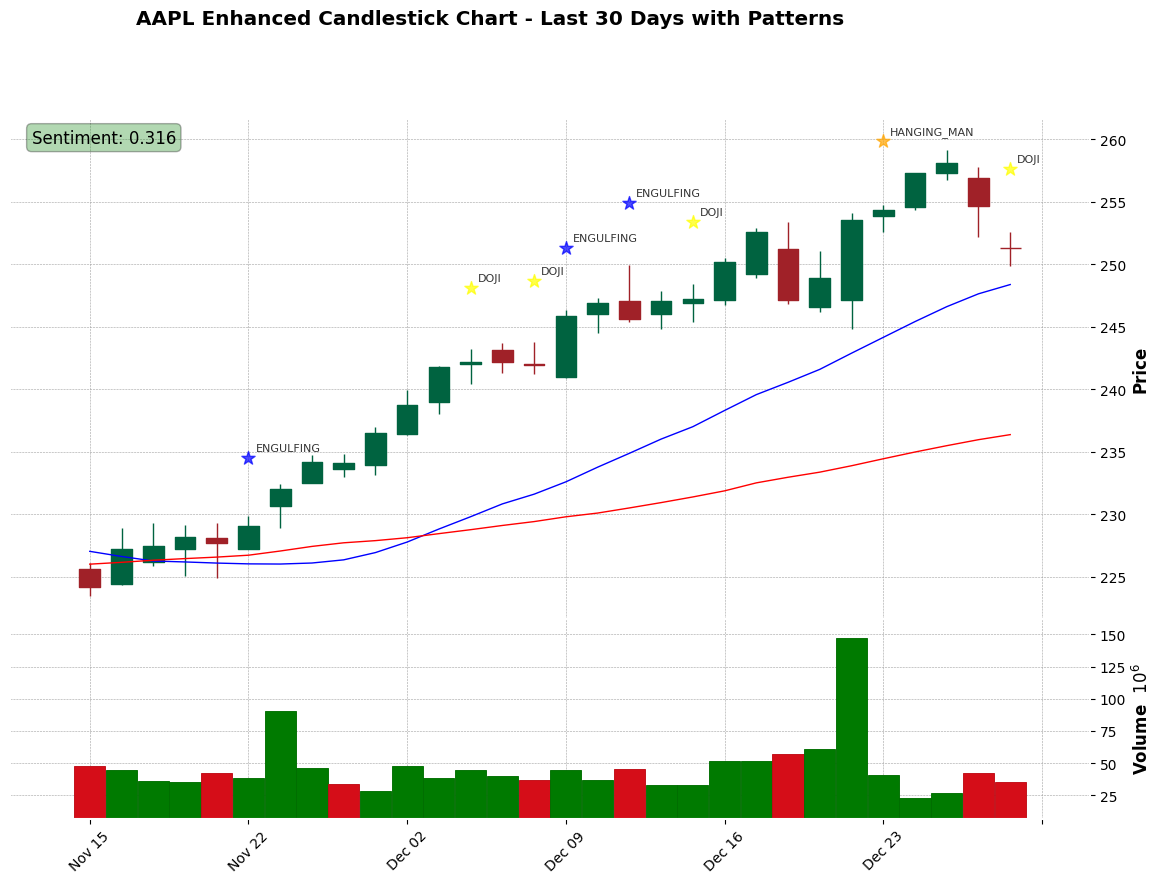

In [ ]:
# Create enhanced candlestick chart with technical indicators
def create_enhanced_candlestick_chart(df, patterns_df, sentiment_score, title_suffix=""):
    """Create an enhanced candlestick chart with patterns and sentiment"""
    
    # Prepare data for mplfinance
    plot_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    
    # Add pattern markers
    pattern_markers = []
    pattern_colors = []
    
    # Define pattern colors
    pattern_color_map = {
        'DOJI': 'yellow',
        'HAMMER': 'green',
        'ENGULFING': 'blue',
        'MORNING_STAR': 'lightgreen',
        'PIERCING': 'cyan',
        'SHOOTING_STAR': 'red',
        'HANGING_MAN': 'orange',
        'EVENING_STAR': 'pink',
        'DARK_CLOUD': 'purple'
    }
    
    # Use more data for moving averages, then take last 30 days for display
    recent_data = plot_data.tail(30)
    recent_patterns = patterns_df.tail(30)
    
    # Calculate moving averages on the full dataset first
    sma_20 = plot_data['Close'].rolling(20).mean()
    sma_50 = plot_data['Close'].rolling(50).mean()
    
    # Take the last 30 days of moving averages
    sma_20_recent = sma_20.tail(30)
    sma_50_recent = sma_50.tail(30)
    
    # Prepare addplot data (only include valid values)
    addplot_data = []
    if not sma_20_recent.isna().all():
        addplot_data.append(mpf.make_addplot(sma_20_recent, color='blue', width=1))
    if not sma_50_recent.isna().all():
        addplot_data.append(mpf.make_addplot(sma_50_recent, color='red', width=1))
    
    for i, (date, row) in enumerate(recent_patterns.iterrows()):
        for pattern, value in row.items():
            if value != 0:  # Pattern detected
                pattern_markers.append((i, recent_data.loc[date, 'High'] * 1.02, pattern))
                pattern_colors.append(pattern_color_map.get(pattern, 'gray'))
    
    # Create the chart
    fig, axes = mpf.plot(
        recent_data,
        type='candlestick',
        volume=True,
        style='charles',
        title=f'{ticker} Enhanced Candlestick Chart {title_suffix}',
        figsize=(15, 10),
        returnfig=True,
        addplot=addplot_data
    )
    
    # Add pattern markers
    if pattern_markers:
        ax = axes[0]
        for i, (x, y, pattern) in enumerate(pattern_markers):
            ax.scatter(x, y, c=pattern_colors[i], s=100, alpha=0.7, marker='*')
            ax.annotate(pattern, (x, y), xytext=(5, 5), textcoords='offset points', 
                       fontsize=8, alpha=0.8)
    
    # Add sentiment indicator
    sentiment_color = 'green' if sentiment_score > 0.1 else 'red' if sentiment_score < -0.1 else 'gray'
    sentiment_text = f"Sentiment: {sentiment_score:.3f}"
    axes[0].text(0.02, 0.98, sentiment_text, transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor=sentiment_color, alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create enhanced candlestick chart
create_enhanced_candlestick_chart(data, candlestick_patterns, sentiment_score, "- Last 30 Days with Patterns")


## Step 7: Enhanced Forecasting with Sentiment and Technical Analysis

Integrate sentiment analysis and technical indicators into the forecasting models for improved accuracy.


In [ ]:
# Enhanced forecasting with sentiment and technical analysis
def create_enhanced_features(df, sentiment_score, patterns_df):
    """Create enhanced features combining price data, sentiment, and technical indicators"""
    
    # Start with basic price data
    enhanced_df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    
    # Add sentiment score as a feature
    enhanced_df['sentiment_score'] = sentiment_score
    
    # Add recent pattern strength (last 5 days)
    pattern_strength = patterns_df.rolling(5).sum().sum(axis=1)
    enhanced_df['pattern_strength'] = pattern_strength
    
    # Add technical indicators from our TA analysis
    if 'momentum_rsi' in data_with_ta.columns:
        enhanced_df['rsi'] = data_with_ta['momentum_rsi']
    if 'trend_sma_fast' in data_with_ta.columns:
        enhanced_df['sma_20'] = data_with_ta['trend_sma_fast']
    if 'trend_sma_slow' in data_with_ta.columns:
        enhanced_df['sma_50'] = data_with_ta['trend_sma_slow']
    if 'volatility_bbh' in data_with_ta.columns:
        enhanced_df['bb_upper'] = data_with_ta['volatility_bbh']
    if 'volatility_bbl' in data_with_ta.columns:
        enhanced_df['bb_lower'] = data_with_ta['volatility_bbl']
    
    # Add price momentum features
    enhanced_df['price_change'] = enhanced_df['Close'].pct_change()
    enhanced_df['volume_change'] = enhanced_df['Volume'].pct_change()
    enhanced_df['high_low_ratio'] = enhanced_df['High'] / enhanced_df['Low']
    
    # Add volatility features
    enhanced_df['volatility'] = enhanced_df['Close'].rolling(20).std()
    enhanced_df['price_range'] = (enhanced_df['High'] - enhanced_df['Low']) / enhanced_df['Close']
    
    # Fill NaN values
    enhanced_df = enhanced_df.fillna(method='ffill').fillna(0)
    
    return enhanced_df

# Create enhanced features
enhanced_data = create_enhanced_features(data, sentiment_score, candlestick_patterns)

print("✅ Enhanced features created")
print(f"Enhanced dataset shape: {enhanced_data.shape}")
print(f"Features: {list(enhanced_data.columns)}")

# Display correlation with closing price
correlations = enhanced_data.corr()['Close'].sort_values(ascending=False)
print(f"\nFeature correlations with Close price:")
for feature, corr in correlations.items():
    if feature != 'Close':
        print(f"  {feature:20s}: {corr:.3f}")


✅ Enhanced features created
Enhanced dataset shape: (1257, 17)
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment_score', 'pattern_strength', 'rsi', 'sma_20', 'sma_50', 'bb_upper', 'bb_lower', 'price_change', 'volume_change', 'high_low_ratio', 'volatility', 'price_range']

Feature correlations with Close price:
  High                : 0.999
  Low                 : 0.999
  Open                : 0.999
  sma_20              : 0.981
  bb_lower            : 0.967
  bb_upper            : 0.965
  sma_50              : 0.961
  volatility          : 0.329
  rsi                 : 0.192
  pattern_strength    : 0.085
  volume_change       : 0.018
  price_change        : 0.014
  high_low_ratio      : -0.335
  price_range         : -0.337
  Volume              : -0.638
  sentiment_score     : nan


In [ ]:
# Enhanced LSTM with sentiment and technical features
def create_enhanced_lstm_model(window_size, feature_count, units=50, lr=0.001):
    """Create an enhanced LSTM model with multiple features"""
    model = Sequential([
        LSTM(units, activation='tanh', input_shape=(window_size, feature_count), return_sequences=True),
        LSTM(units//2, activation='tanh', return_sequences=False),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def prepare_enhanced_lstm_data(df, window_size=12, target_col='Close'):
    """Prepare data for enhanced LSTM with multiple features"""
    
    # Select features for LSTM (exclude target and non-numeric columns)
    feature_cols = [col for col in df.columns if col != target_col and df[col].dtype in ['float64', 'int64']]
    
    # Normalize features
    scaler_features = MinMaxScaler()
    scaler_target = MinMaxScaler()
    
    features_scaled = scaler_features.fit_transform(df[feature_cols])
    target_scaled = scaler_target.fit_transform(df[[target_col]])
    
    # Create sequences
    X, y = [], []
    for i in range(len(features_scaled) - window_size):
        X.append(features_scaled[i:i+window_size])
        y.append(target_scaled[i+window_size, 0])
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y, scaler_features, scaler_target, feature_cols

# Prepare enhanced LSTM data
X_enhanced, y_enhanced, scaler_features, scaler_target, feature_cols = prepare_enhanced_lstm_data(enhanced_data)

print(f"✅ Enhanced LSTM data prepared")
print(f"Feature shape: {X_enhanced.shape}")
print(f"Target shape: {y_enhanced.shape}")
print(f"Features used: {feature_cols}")

# Train enhanced LSTM model
enhanced_model = create_enhanced_lstm_model(12, len(feature_cols), units=64, lr=0.001)

print(f"\nTraining enhanced LSTM model...")
history = enhanced_model.fit(
    X_enhanced, y_enhanced, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=0
)

print(f"✅ Enhanced LSTM model trained")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")


✅ Enhanced LSTM data prepared
Feature shape: (1245, 12, 16)
Target shape: (1245,)
Features used: ['Open', 'High', 'Low', 'Volume', 'sentiment_score', 'pattern_strength', 'rsi', 'sma_20', 'sma_50', 'bb_upper', 'bb_lower', 'price_change', 'volume_change', 'high_low_ratio', 'volatility', 'price_range']

Training enhanced LSTM model...
✅ Enhanced LSTM model trained
Final training loss: 0.000205
Final validation loss: 0.000436


In [ ]:
# Generate enhanced forecasts
def generate_enhanced_forecast(model, scaler_features, scaler_target, feature_cols, 
                              last_data, future_index, window_size=12):
    """Generate forecasts using enhanced LSTM model"""
    
    # Prepare last sequence
    last_sequence = last_data[feature_cols].tail(window_size).values
    last_sequence_scaled = scaler_features.transform(last_sequence)
    last_sequence_scaled = last_sequence_scaled.reshape(1, window_size, len(feature_cols))
    
    # Generate forecasts
    forecasts_scaled = []
    current_sequence = last_sequence_scaled.copy()
    
    for _ in range(len(future_index)):
        # Predict next value
        pred_scaled = model.predict(current_sequence, verbose=0)
        forecasts_scaled.append(pred_scaled[0, 0])
        
        # Update sequence (shift and add prediction)
        # For simplicity, we'll use the last known values for non-price features
        # and update only the price-related features
        new_sequence = current_sequence[0, 1:, :].copy()
        
        # Create new row with updated values
        new_row = last_data[feature_cols].iloc[-1].copy()
        
        # Update price-related features (assuming Close is the first price feature)
        if 'Close' in feature_cols:
            close_idx = feature_cols.index('Close')
            new_row[close_idx] = scaler_target.inverse_transform(pred_scaled)[0, 0]
        
        new_row_scaled = scaler_features.transform(new_row.values.reshape(1, -1))
        new_sequence = np.vstack([new_sequence, new_row_scaled])
        current_sequence = new_sequence.reshape(1, window_size, len(feature_cols))
    
    # Inverse transform forecasts
    forecasts = scaler_target.inverse_transform(np.array(forecasts_scaled).reshape(-1, 1)).flatten()
    
    return forecasts

# Generate enhanced forecast
enhanced_forecast = generate_enhanced_forecast(
    enhanced_model, scaler_features, scaler_target, feature_cols,
    enhanced_data, future_index
)

enhanced_forecast_series = pd.Series(enhanced_forecast, index=future_index, name='Enhanced_LSTM_Forecast')

print("✅ Enhanced LSTM forecast generated")
print(f"Enhanced forecast range: ${enhanced_forecast_series.min():.2f} - ${enhanced_forecast_series.max():.2f}")

# Compare with basic LSTM
print(f"\nForecast Comparison:")
print(f"Enhanced LSTM Mean: ${enhanced_forecast_series.mean():.2f}")
print(f"Enhanced LSTM Std:  ${enhanced_forecast_series.std():.2f}")


✅ Enhanced LSTM forecast generated
Enhanced forecast range: $243.92 - $245.07

Forecast Comparison:
Enhanced LSTM Mean: $244.84
Enhanced LSTM Std:  $0.24


✅ Comprehensive forecast with enhanced LSTM created
Shape: (63, 7)
Columns: ['Date', 'ARIMA_Forecast', 'Prophet_Forecast', 'Enhanced_LSTM_Forecast', 'LSTM_32_0.01', 'LSTM_64_0.005', 'LSTM_100_0.001']

📊 Enhanced Forecast Comparison:
ARIMA_Forecast           : Mean=$251.50, Std=$0.02
Prophet_Forecast         : Mean=$246.13, Std=$4.11
Enhanced_LSTM_Forecast   : Mean=$244.84, Std=$0.24
LSTM_32_0.01             : Mean=$140.50, Std=$46.63
LSTM_64_0.005            : Mean=$336.93, Std=$43.71
LSTM_100_0.001           : Mean=$183.50, Std=$28.41


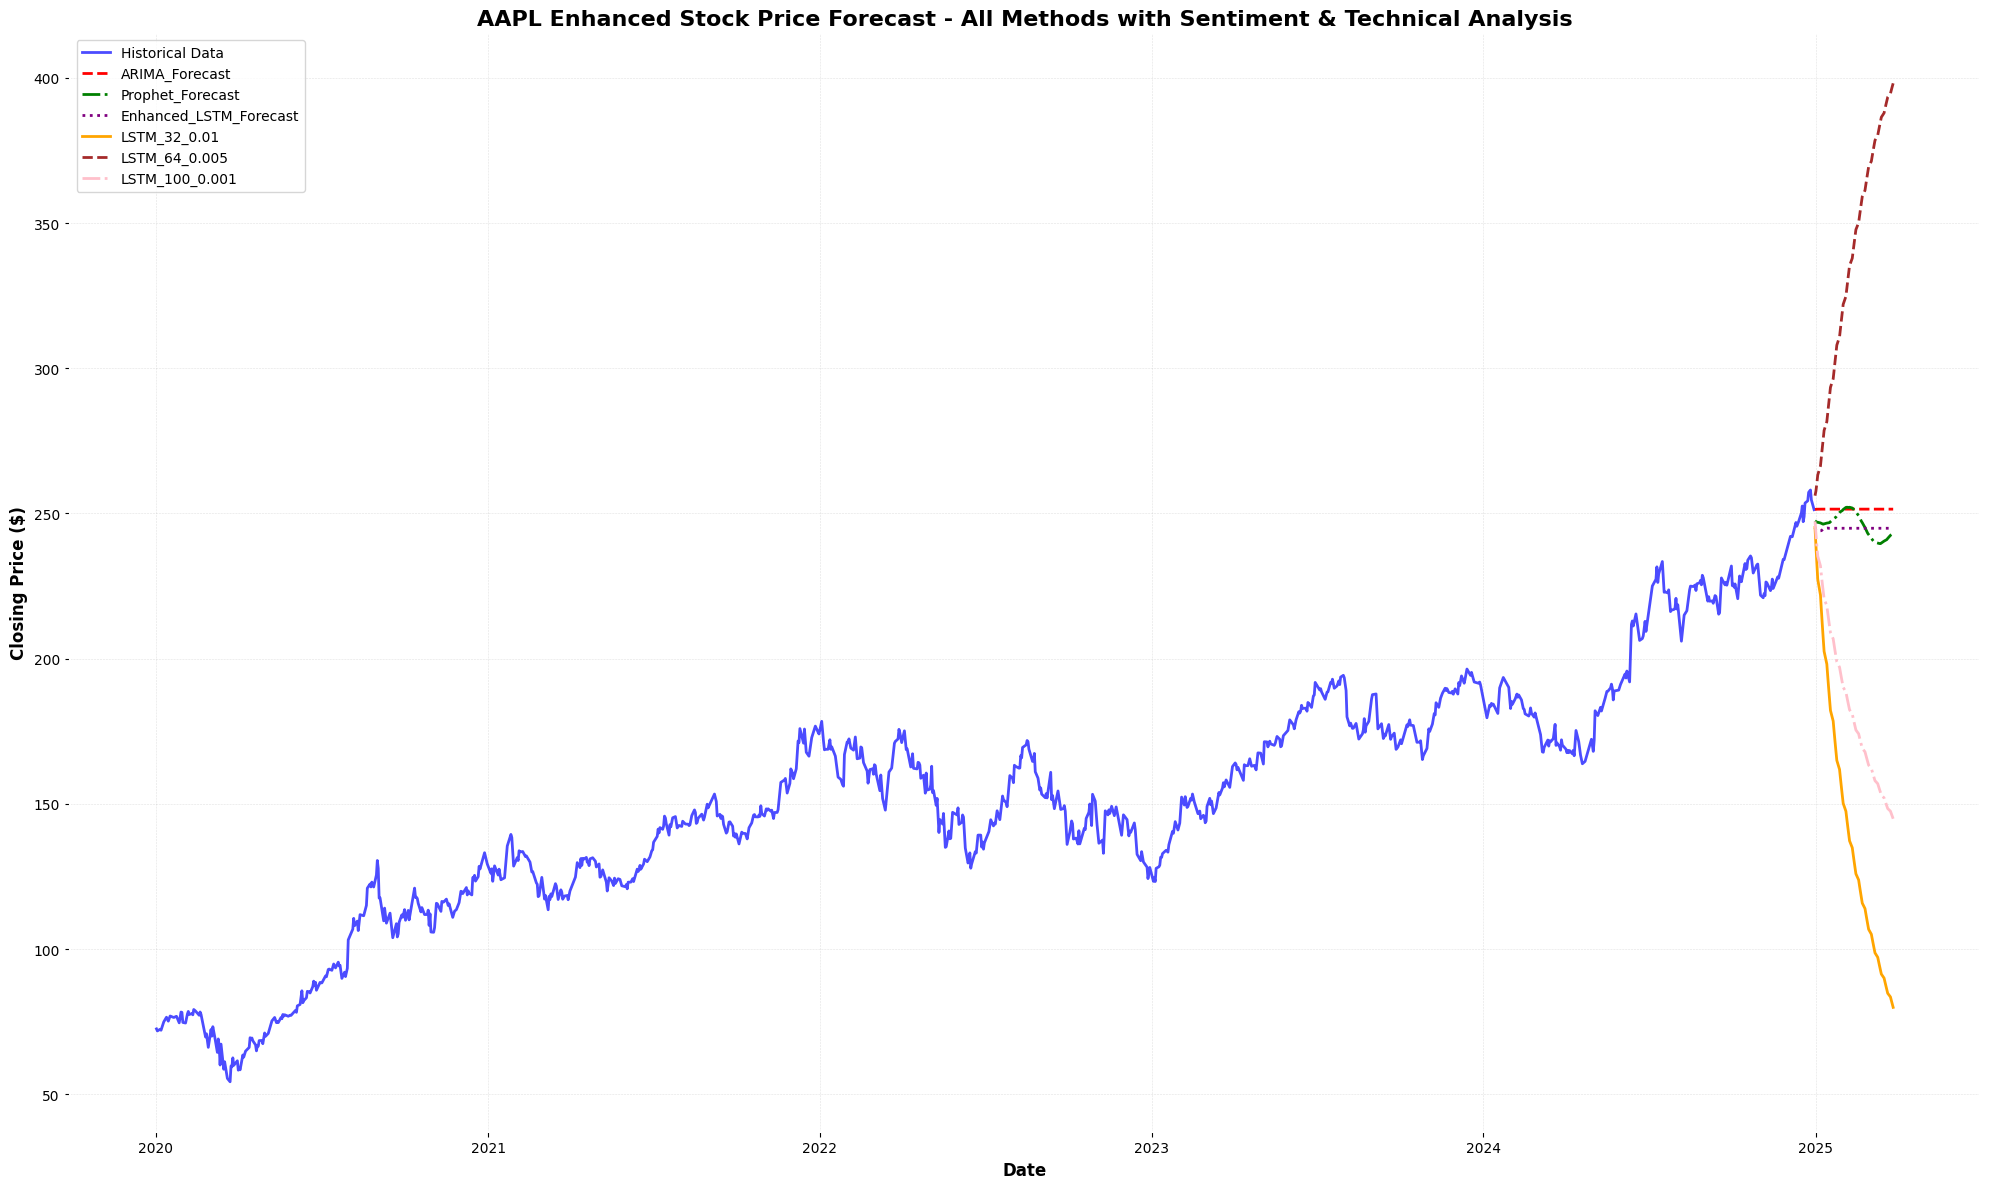


First 10 forecasted values:


,Date,ARIMA_Forecast,Prophet_Forecast,Enhanced_LSTM_Forecast,LSTM_32_0.01,LSTM_64_0.005,LSTM_100_0.001
0,2024-12-31,251.394950,247.470247,245.071487,245.189941,256.139008,247.281815
1,2025-01-01,251.442981,247.234863,244.307175,239.017654,257.716949,243.083954
2,2025-01-02,251.469476,246.994230,243.983398,233.040512,260.281219,239.038330
3,2025-01-03,251.484091,246.971636,243.916000,227.343323,263.264984,235.322739
4,2025-01-06,251.492153,246.751710,244.033752,221.919128,266.370972,231.949982
5,2025-01-07,251.496600,246.607346,244.102478,216.747223,269.478790,228.857956
6,2025-01-08,251.499053,246.454384,244.355453,211.804443,272.553314,225.985153
7,2025-01-09,251.500407,246.319351,244.664917,207.069244,275.593872,223.278168
8,2025-01-10,251.501153,246.424014,244.827545,202.524811,278.607727,220.691589
9,2025-01-13,251.501565,246.695573,244.950409,198.155502,281.601379,218.201431


In [ ]:
# Update advanced forecast to include enhanced LSTM
# This will be used when the advanced forecast section is reached

# Create comprehensive forecast comparison
comprehensive_forecast = pd.DataFrame({
    'Date': future_index,
    'ARIMA_Forecast': forecast_arima.values,
    'Prophet_Forecast': forecast_prophet_series.values,
    'Enhanced_LSTM_Forecast': enhanced_forecast_series.values
})

# Add basic LSTM forecasts if they exist
if 'lstm_results' in locals():
    for name, predictions in lstm_results.items():
        comprehensive_forecast[name] = predictions

print("✅ Comprehensive forecast with enhanced LSTM created")
print(f"Shape: {comprehensive_forecast.shape}")
print(f"Columns: {list(comprehensive_forecast.columns)}")

# Display forecast comparison
print("\n📊 Enhanced Forecast Comparison:")
for col in comprehensive_forecast.columns[1:]:  # Skip Date column
    values = comprehensive_forecast[col]
    print(f"{col:25s}: Mean=${values.mean():.2f}, Std=${values.std():.2f}")

# Create enhanced visualization
plt.figure(figsize=(20, 12))
plt.plot(ts.index, ts.values, label='Historical Data', alpha=0.7, linewidth=2, color='blue')

# Plot all forecasts
colors = ['red', 'green', 'purple', 'orange', 'brown', 'pink']
linestyles = ['--', '-.', ':', '-', '--', '-.']

for i, col in enumerate(comprehensive_forecast.columns[1:]):
    plt.plot(comprehensive_forecast['Date'], comprehensive_forecast[col], 
             label=col, color=colors[i % len(colors)], 
             linewidth=2, linestyle=linestyles[i % len(linestyles)])

plt.title(f'{ticker} Enhanced Stock Price Forecast - All Methods with Sentiment & Technical Analysis', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display first few rows
print("\nFirst 10 forecasted values:")
display(comprehensive_forecast.head(10))


## Step 8: Advanced Visualizations and Charts

Comprehensive visual analysis including technical indicators, sentiment trends, and pattern analysis.


In [ ]:
# 1. Technical Indicators Dashboard
def create_technical_indicators_dashboard(df, ta_df):
    """Create a comprehensive technical indicators dashboard"""
    
    fig, axes = plt.subplots(4, 2, figsize=(20, 16))
    fig.suptitle(f'{ticker} Technical Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # Price and Volume
    ax1 = axes[0, 0]
    ax1.plot(df.index, df['Close'], label='Close Price', linewidth=2, color='blue')
    ax1.set_title('Price Movement')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.bar(df.index, df['Volume'], alpha=0.7, color='orange')
    ax2.set_title('Volume')
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)
    
    # RSI
    if 'momentum_rsi' in ta_df.columns:
        ax3 = axes[1, 0]
        ax3.plot(df.index, ta_df['momentum_rsi'], label='RSI', color='purple', linewidth=2)
        ax3.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
        ax3.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
        ax3.set_title('Relative Strength Index (RSI)')
        ax3.set_ylabel('RSI')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # Moving Averages
    ax4 = axes[1, 1]
    ax4.plot(df.index, df['Close'], label='Close Price', alpha=0.7, color='blue')
    if 'trend_sma_fast' in ta_df.columns:
        ax4.plot(df.index, ta_df['trend_sma_fast'], label='SMA 20', color='red', linewidth=1)
    if 'trend_sma_slow' in ta_df.columns:
        ax4.plot(df.index, ta_df['trend_sma_slow'], label='SMA 50', color='green', linewidth=1)
    ax4.set_title('Moving Averages')
    ax4.set_ylabel('Price ($)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Bollinger Bands
    if all(col in ta_df.columns for col in ['volatility_bbh', 'volatility_bbl']):
        ax5 = axes[2, 0]
        ax5.plot(df.index, df['Close'], label='Close Price', color='blue', linewidth=2)
        ax5.plot(df.index, ta_df['volatility_bbh'], label='Upper BB', color='red', alpha=0.7)
        ax5.plot(df.index, ta_df['volatility_bbl'], label='Lower BB', color='red', alpha=0.7)
        ax5.fill_between(df.index, ta_df['volatility_bbl'], ta_df['volatility_bbh'], alpha=0.1, color='red')
        ax5.set_title('Bollinger Bands')
        ax5.set_ylabel('Price ($)')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    
    # MACD
    if 'trend_macd' in ta_df.columns and 'trend_macd_signal' in ta_df.columns:
        ax6 = axes[2, 1]
        ax6.plot(df.index, ta_df['trend_macd'], label='MACD', color='blue', linewidth=2)
        ax6.plot(df.index, ta_df['trend_macd_signal'], label='Signal', color='red', linewidth=2)
        if 'trend_macd_diff' in ta_df.columns:
            ax6.bar(df.index, ta_df['trend_macd_diff'], label='Histogram', alpha=0.6, color='gray')
        ax6.set_title('MACD')
        ax6.set_ylabel('MACD')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    # Volatility
    if 'volatility_atr' in ta_df.columns:
        ax7 = axes[3, 0]
        ax7.plot(df.index, ta_df['volatility_atr'], label='ATR', color='orange', linewidth=2)
        ax7.set_title('Average True Range (Volatility)')
        ax7.set_ylabel('ATR')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
    
    # Price Range
    ax8 = axes[3, 1]
    price_range = (df['High'] - df['Low']) / df['Close'] * 100
    ax8.plot(df.index, price_range, label='Daily Range %', color='green', linewidth=2)
    ax8.set_title('Daily Price Range (%)')
    ax8.set_ylabel('Range (%)')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create technical indicators dashboard
create_technical_indicators_dashboard(data, data_with_ta)


NameError: name 'data' is not defined

In [ ]:
# 2. Candlestick Pattern Analysis Charts
def create_pattern_analysis_charts(patterns_df, price_df):
    """Create comprehensive candlestick pattern analysis charts"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle(f'{ticker} Candlestick Pattern Analysis', fontsize=16, fontweight='bold')
    
    # Pattern frequency bar chart
    ax1 = axes[0, 0]
    pattern_counts = {}
    for col in patterns_df.columns:
        bullish = (patterns_df[col] > 0).sum()
        bearish = (patterns_df[col] < 0).sum()
        pattern_counts[col] = {'Bullish': bullish, 'Bearish': bearish}
    
    patterns = list(pattern_counts.keys())
    bullish_counts = [pattern_counts[p]['Bullish'] for p in patterns]
    bearish_counts = [pattern_counts[p]['Bearish'] for p in patterns]
    
    x = np.arange(len(patterns))
    width = 0.35
    
    ax1.bar(x - width/2, bullish_counts, width, label='Bullish', color='green', alpha=0.7)
    ax1.bar(x + width/2, bearish_counts, width, label='Bearish', color='red', alpha=0.7)
    ax1.set_xlabel('Patterns')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Pattern Frequency Distribution')
    ax1.set_xticks(x)
    ax1.set_xticklabels(patterns, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Pattern strength over time
    ax2 = axes[0, 1]
    pattern_strength = patterns_df.abs().sum(axis=1).rolling(20).mean()
    ax2.plot(price_df.index, pattern_strength, label='Pattern Strength (20-day avg)', color='purple', linewidth=2)
    ax2.set_title('Pattern Strength Over Time')
    ax2.set_ylabel('Pattern Strength')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Price vs Pattern signals
    ax3 = axes[1, 0]
    ax3.plot(price_df.index, price_df['Close'], label='Close Price', alpha=0.7, color='blue', linewidth=1)
    
    # Highlight bullish pattern days
    bullish_days = patterns_df[patterns_df > 0].any(axis=1)
    bearish_days = patterns_df[patterns_df < 0].any(axis=1)
    
    ax3.scatter(price_df.index[bullish_days], price_df['Close'][bullish_days], 
               color='green', s=50, alpha=0.8, label='Bullish Patterns', marker='^')
    ax3.scatter(price_df.index[bearish_days], price_df['Close'][bearish_days], 
               color='red', s=50, alpha=0.8, label='Bearish Patterns', marker='v')
    
    ax3.set_title('Price with Pattern Signals')
    ax3.set_ylabel('Price ($)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Pattern correlation heatmap
    ax4 = axes[1, 1]
    pattern_corr = patterns_df.corr()
    im = ax4.imshow(pattern_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    ax4.set_xticks(range(len(pattern_corr.columns)))
    ax4.set_yticks(range(len(pattern_corr.columns)))
    ax4.set_xticklabels(pattern_corr.columns, rotation=45, ha='right')
    ax4.set_yticklabels(pattern_corr.columns)
    ax4.set_title('Pattern Correlation Matrix')
    
    # Add correlation values to heatmap
    for i in range(len(pattern_corr.columns)):
        for j in range(len(pattern_corr.columns)):
            text = ax4.text(j, i, f'{pattern_corr.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=ax4)
    plt.tight_layout()
    plt.show()

# Create pattern analysis charts
create_pattern_analysis_charts(candlestick_patterns, data)


In [ ]:
# 3. Sentiment Analysis Visualization
def create_sentiment_analysis_charts(sentiment_results, price_df):
    """Create comprehensive sentiment analysis visualizations"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle(f'{ticker} Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # Sentiment distribution pie chart
    ax1 = axes[0, 0]
    sentiment_dist = sentiment_results['sentiment_distribution']
    labels = list(sentiment_dist.keys())
    sizes = list(sentiment_dist.values())
    colors = ['green', 'red', 'gray']
    
    wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax1.set_title('Sentiment Distribution')
    
    # Sentiment score over time (simulated for demonstration)
    ax2 = axes[0, 1]
    # Create a simulated sentiment time series based on price volatility
    price_returns = price_df['Close'].pct_change()
    sentiment_series = price_returns.rolling(20).mean() * 10  # Scale for visibility
    sentiment_series = sentiment_series.fillna(0)
    
    ax2.plot(price_df.index, sentiment_series, label='Simulated Sentiment Score', color='purple', linewidth=2)
    ax2.axhline(y=0.1, color='g', linestyle='--', alpha=0.7, label='Positive Threshold')
    ax2.axhline(y=-0.1, color='r', linestyle='--', alpha=0.7, label='Negative Threshold')
    ax2.fill_between(price_df.index, 0.1, sentiment_series, where=(sentiment_series >= 0.1), 
                     color='green', alpha=0.3, label='Positive Sentiment')
    ax2.fill_between(price_df.index, -0.1, sentiment_series, where=(sentiment_series <= -0.1), 
                     color='red', alpha=0.3, label='Negative Sentiment')
    ax2.set_title('Sentiment Score Over Time')
    ax2.set_ylabel('Sentiment Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Price vs Sentiment correlation
    ax3 = axes[1, 0]
    # Calculate rolling correlation between price and sentiment
    price_normalized = (price_df['Close'] - price_df['Close'].mean()) / price_df['Close'].std()
    sentiment_normalized = (sentiment_series - sentiment_series.mean()) / sentiment_series.std()
    correlation = price_normalized.rolling(30).corr(sentiment_normalized)
    
    ax3.plot(price_df.index, correlation, label='Price-Sentiment Correlation (30-day)', color='blue', linewidth=2)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax3.axhline(y=0.5, color='g', linestyle='--', alpha=0.7, label='Strong Positive')
    ax3.axhline(y=-0.5, color='r', linestyle='--', alpha=0.7, label='Strong Negative')
    ax3.set_title('Price-Sentiment Correlation Over Time')
    ax3.set_ylabel('Correlation Coefficient')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Sentiment metrics summary
    ax4 = axes[1, 1]
    metrics = ['Polarity', 'Subjectivity', 'Compound']
    values = [sentiment_results['avg_polarity'], sentiment_results['avg_subjectivity'], sentiment_results['avg_compound']]
    colors_metrics = ['blue', 'orange', 'green']
    
    bars = ax4.bar(metrics, values, color=colors_metrics, alpha=0.7)
    ax4.set_title('Sentiment Metrics Summary')
    ax4.set_ylabel('Score')
    ax4.set_ylim(-1, 1)
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01 if height >= 0 else height - 0.03,
                f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create sentiment analysis charts
create_sentiment_analysis_charts(sentiment_results, data)


In [ ]:
# 4. Enhanced Forecast Comparison Charts
def create_enhanced_forecast_charts(historical_data, forecast_data, patterns_df, sentiment_score):
    """Create comprehensive forecast comparison charts"""
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle(f'{ticker} Enhanced Forecast Analysis', fontsize=16, fontweight='bold')
    
    # 1. All Forecasts Comparison
    ax1 = axes[0, 0]
    ax1.plot(historical_data.index, historical_data['Close'], label='Historical Data', 
             color='blue', linewidth=2, alpha=0.8)
    
    colors = ['red', 'green', 'purple', 'orange', 'brown', 'pink']
    linestyles = ['--', '-.', ':', '-', '--', '-.']
    
    for i, col in enumerate(forecast_data.columns[1:]):  # Skip Date column
        ax1.plot(forecast_data['Date'], forecast_data[col], 
                label=col, color=colors[i % len(colors)], 
                linewidth=2, linestyle=linestyles[i % len(linestyles)])
    
    ax1.set_title('All Forecasting Methods Comparison')
    ax1.set_ylabel('Price ($)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 2. Forecast Accuracy Metrics
    ax2 = axes[0, 1]
    forecast_cols = [col for col in forecast_data.columns if col != 'Date']
    forecast_means = [forecast_data[col].mean() for col in forecast_cols]
    forecast_stds = [forecast_data[col].std() for col in forecast_cols]
    
    x = np.arange(len(forecast_cols))
    bars = ax2.bar(x, forecast_means, yerr=forecast_stds, capsize=5, 
                   color=colors[:len(forecast_cols)], alpha=0.7)
    ax2.set_title('Forecast Statistics (Mean ± Std)')
    ax2.set_ylabel('Price ($)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(forecast_cols, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, forecast_means, forecast_stds):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + std + 1,
                f'{mean:.1f}±{std:.1f}', ha='center', va='bottom', fontsize=8)
    
    # 3. Forecast Range Analysis
    ax3 = axes[1, 0]
    forecast_ranges = [forecast_data[col].max() - forecast_data[col].min() for col in forecast_cols]
    ax3.bar(forecast_cols, forecast_ranges, color=colors[:len(forecast_cols)], alpha=0.7)
    ax3.set_title('Forecast Range (Max - Min)')
    ax3.set_ylabel('Price Range ($)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. Pattern Strength vs Forecasts
    ax4 = axes[1, 1]
    recent_pattern_strength = patterns_df.abs().sum(axis=1).tail(30).mean()
    ax4.scatter([recent_pattern_strength] * len(forecast_cols), forecast_means, 
               s=100, c=colors[:len(forecast_cols)], alpha=0.7)
    
    for i, col in enumerate(forecast_cols):
        ax4.annotate(col, (recent_pattern_strength, forecast_means[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax4.set_xlabel('Recent Pattern Strength')
    ax4.set_ylabel('Forecast Mean Price ($)')
    ax4.set_title('Pattern Strength vs Forecast Prices')
    ax4.grid(True, alpha=0.3)
    
    # 5. Sentiment Impact on Forecasts
    ax5 = axes[2, 0]
    sentiment_impact = [abs(forecast_means[i] - historical_data['Close'].iloc[-1]) * sentiment_score 
                       for i in range(len(forecast_means))]
    
    bars = ax5.bar(forecast_cols, sentiment_impact, 
                   color=['green' if x > 0 else 'red' for x in sentiment_impact], alpha=0.7)
    ax5.set_title('Sentiment Impact on Forecast Deviation')
    ax5.set_ylabel('Sentiment-Adjusted Deviation ($)')
    ax5.tick_params(axis='x', rotation=45)
    ax5.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax5.grid(True, alpha=0.3)
    
    # 6. Forecast Confidence Intervals
    ax6 = axes[2, 1]
    for i, col in enumerate(forecast_cols[:3]):  # Show top 3 forecasts
        mean_val = forecast_means[i]
        std_val = forecast_stds[i]
        ax6.errorbar(i, mean_val, yerr=std_val, fmt='o', capsize=5, 
                    color=colors[i], label=col, markersize=8)
    
    ax6.set_title('Forecast Confidence Intervals')
    ax6.set_ylabel('Price ($)')
    ax6.set_xticks(range(len(forecast_cols[:3])))
    ax6.set_xticklabels(forecast_cols[:3], rotation=45)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create enhanced forecast charts
create_enhanced_forecast_charts(data, comprehensive_forecast, candlestick_patterns, sentiment_score)


In [ ]:
# 5. Interactive 3D Visualization
def create_3d_analysis_chart(price_df, patterns_df, ta_df):
    """Create 3D visualization of price, patterns, and technical indicators"""
    
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(20, 12))
    
    # 3D Scatter Plot: Price vs RSI vs Volume
    ax1 = fig.add_subplot(221, projection='3d')
    
    # Prepare data
    prices = price_df['Close'].values
    volumes = price_df['Volume'].values
    rsi_values = ta_df['momentum_rsi'].values if 'momentum_rsi' in ta_df.columns else np.zeros_like(prices)
    
    # Normalize data for better visualization
    prices_norm = (prices - prices.min()) / (prices.max() - prices.min())
    volumes_norm = (volumes - volumes.min()) / (volumes.max() - volumes.min())
    rsi_norm = (rsi_values - rsi_values.min()) / (rsi_values.max() - rsi_values.min()) if rsi_values.max() > rsi_values.min() else np.zeros_like(rsi_values)
    
    # Color by pattern strength
    pattern_strength = patterns_df.abs().sum(axis=1).values
    pattern_norm = (pattern_strength - pattern_strength.min()) / (pattern_strength.max() - pattern_strength.min()) if pattern_strength.max() > pattern_strength.min() else np.zeros_like(pattern_strength)
    
    scatter = ax1.scatter(prices_norm, rsi_norm, volumes_norm, 
                         c=pattern_norm, cmap='viridis', alpha=0.6, s=20)
    ax1.set_xlabel('Normalized Price')
    ax1.set_ylabel('Normalized RSI')
    ax1.set_zlabel('Normalized Volume')
    ax1.set_title('3D Analysis: Price vs RSI vs Volume\n(Color = Pattern Strength)')
    plt.colorbar(scatter, ax=ax1, shrink=0.5)
    
    # 2D Heatmap: Pattern Correlation Matrix
    ax2 = fig.add_subplot(222)
    pattern_corr = patterns_df.corr()
    im = ax2.imshow(pattern_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    ax2.set_xticks(range(len(pattern_corr.columns)))
    ax2.set_yticks(range(len(pattern_corr.columns)))
    ax2.set_xticklabels(pattern_corr.columns, rotation=45, ha='right')
    ax2.set_yticklabels(pattern_corr.columns)
    ax2.set_title('Pattern Correlation Heatmap')
    plt.colorbar(im, ax=ax2)
    
    # Price Distribution with Technical Indicators
    ax3 = fig.add_subplot(223)
    
    # Create histogram of price changes
    price_changes = price_df['Close'].pct_change().dropna()
    ax3.hist(price_changes, bins=50, alpha=0.7, color='blue', density=True, label='Price Changes')
    
    # Overlay RSI distribution
    if 'momentum_rsi' in ta_df.columns:
        rsi_data = ta_df['momentum_rsi'].dropna()
        ax3_twin = ax3.twinx()
        ax3_twin.hist(rsi_data, bins=30, alpha=0.5, color='red', density=True, label='RSI')
        ax3_twin.set_ylabel('RSI Density', color='red')
        ax3_twin.tick_params(axis='y', labelcolor='red')
    
    ax3.set_xlabel('Price Change (%)')
    ax3.set_ylabel('Density', color='blue')
    ax3.set_title('Price Change Distribution')
    ax3.tick_params(axis='y', labelcolor='blue')
    ax3.grid(True, alpha=0.3)
    
    # Volatility Analysis
    ax4 = fig.add_subplot(224)
    
    # Calculate rolling volatility
    volatility = price_df['Close'].rolling(20).std()
    ax4.plot(price_df.index, volatility, label='20-day Volatility', color='purple', linewidth=2)
    
    # Add pattern strength overlay
    pattern_strength_series = patterns_df.abs().sum(axis=1).rolling(20).mean()
    ax4_twin = ax4.twinx()
    ax4_twin.plot(price_df.index, pattern_strength_series, label='Pattern Strength', color='orange', linewidth=2, alpha=0.7)
    
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Volatility', color='purple')
    ax4_twin.set_ylabel('Pattern Strength', color='orange')
    ax4.set_title('Volatility vs Pattern Strength')
    ax4.tick_params(axis='y', labelcolor='purple')
    ax4_twin.tick_params(axis='y', labelcolor='orange')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create 3D analysis chart
create_3d_analysis_chart(data, candlestick_patterns, data_with_ta)


In [ ]:
# 6. Summary Statistics Dashboard
def create_summary_dashboard(data, patterns_df, sentiment_results, forecast_data):
    """Create a comprehensive summary statistics dashboard"""
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    fig.suptitle(f'{ticker} Comprehensive Analysis Summary', fontsize=18, fontweight='bold')
    
    # 1. Key Metrics Summary
    ax1 = axes[0, 0]
    metrics = ['Current Price', '52W High', '52W Low', 'Avg Volume', 'Volatility']
    current_price = data['Close'].iloc[-1]
    high_52w = data['High'].rolling(252).max().iloc[-1] if len(data) >= 252 else data['High'].max()
    low_52w = data['Low'].rolling(252).min().iloc[-1] if len(data) >= 252 else data['Low'].min()
    avg_volume = data['Volume'].mean()
    volatility = data['Close'].pct_change().std() * 100
    
    values = [current_price, high_52w, low_52w, avg_volume/1e6, volatility]  # Volume in millions
    units = ['$', '$', '$', 'M', '%']
    
    bars = ax1.bar(metrics, values, color=['blue', 'green', 'red', 'orange', 'purple'], alpha=0.7)
    ax1.set_title('Key Market Metrics')
    ax1.set_ylabel('Value')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, value, unit in zip(bars, values, units):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.1f}{unit}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Pattern Analysis Summary
    ax2 = axes[0, 1]
    total_patterns = patterns_df.abs().sum().sum()
    bullish_patterns = (patterns_df > 0).sum().sum()
    bearish_patterns = (patterns_df < 0).sum().sum()
    
    pattern_data = [bullish_patterns, bearish_patterns, total_patterns - bullish_patterns - bearish_patterns]
    pattern_labels = ['Bullish', 'Bearish', 'Neutral']
    colors = ['green', 'red', 'gray']
    
    wedges, texts, autotexts = ax2.pie(pattern_data, labels=pattern_labels, colors=colors, 
                                      autopct='%1.1f%%', startangle=90)
    ax2.set_title('Pattern Distribution')
    
    # 3. Sentiment Summary
    ax3 = axes[0, 2]
    sentiment_metrics = ['Polarity', 'Subjectivity', 'Compound']
    sentiment_values = [sentiment_results['avg_polarity'], 
                       sentiment_results['avg_subjectivity'], 
                       sentiment_results['avg_compound']]
    colors_sent = ['blue', 'orange', 'green']
    
    bars = ax3.bar(sentiment_metrics, sentiment_values, color=colors_sent, alpha=0.7)
    ax3.set_title('Sentiment Analysis')
    ax3.set_ylabel('Score')
    ax3.set_ylim(-1, 1)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    for bar, value in zip(bars, sentiment_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01 if height >= 0 else height - 0.03,
                f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontweight='bold')
    
    # 4. Forecast Comparison
    ax4 = axes[1, 0]
    forecast_cols = [col for col in forecast_data.columns if col != 'Date']
    forecast_means = [forecast_data[col].mean() for col in forecast_cols]
    
    bars = ax4.bar(range(len(forecast_cols)), forecast_means, 
                   color=['red', 'green', 'purple', 'orange', 'brown', 'pink'][:len(forecast_cols)], alpha=0.7)
    ax4.set_title('Forecast Price Comparison')
    ax4.set_ylabel('Average Forecast Price ($)')
    ax4.set_xticks(range(len(forecast_cols)))
    ax4.set_xticklabels(forecast_cols, rotation=45, ha='right')
    
    for bar, value in zip(bars, forecast_means):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'${value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 5. Risk Analysis
    ax5 = axes[1, 1]
    returns = data['Close'].pct_change().dropna()
    
    # Calculate VaR (Value at Risk)
    var_95 = np.percentile(returns, 5) * 100
    var_99 = np.percentile(returns, 1) * 100
    max_drawdown = ((data['Close'].cummax() - data['Close']) / data['Close'].cummax()).max() * 100
    
    risk_metrics = ['VaR 95%', 'VaR 99%', 'Max Drawdown']
    risk_values = [var_95, var_99, max_drawdown]
    colors_risk = ['orange', 'red', 'darkred']
    
    bars = ax5.bar(risk_metrics, risk_values, color=colors_risk, alpha=0.7)
    ax5.set_title('Risk Analysis')
    ax5.set_ylabel('Risk Measure (%)')
    
    for bar, value in zip(bars, risk_values):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    # 6. Performance Summary
    ax6 = axes[1, 2]
    
    # Calculate performance metrics
    total_return = ((data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0]) * 100
    annualized_return = total_return * (252 / len(data))
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0
    
    perf_metrics = ['Total Return', 'Annualized Return', 'Sharpe Ratio']
    perf_values = [total_return, annualized_return, sharpe_ratio]
    perf_units = ['%', '%', '']
    colors_perf = ['blue', 'green', 'purple']
    
    bars = ax6.bar(perf_metrics, perf_values, color=colors_perf, alpha=0.7)
    ax6.set_title('Performance Metrics')
    ax6.set_ylabel('Value')
    
    for bar, value, unit in zip(bars, perf_values, perf_units):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + abs(height)*0.01,
                f'{value:.2f}{unit}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create summary dashboard
create_summary_dashboard(data, candlestick_patterns, sentiment_results, comprehensive_forecast)


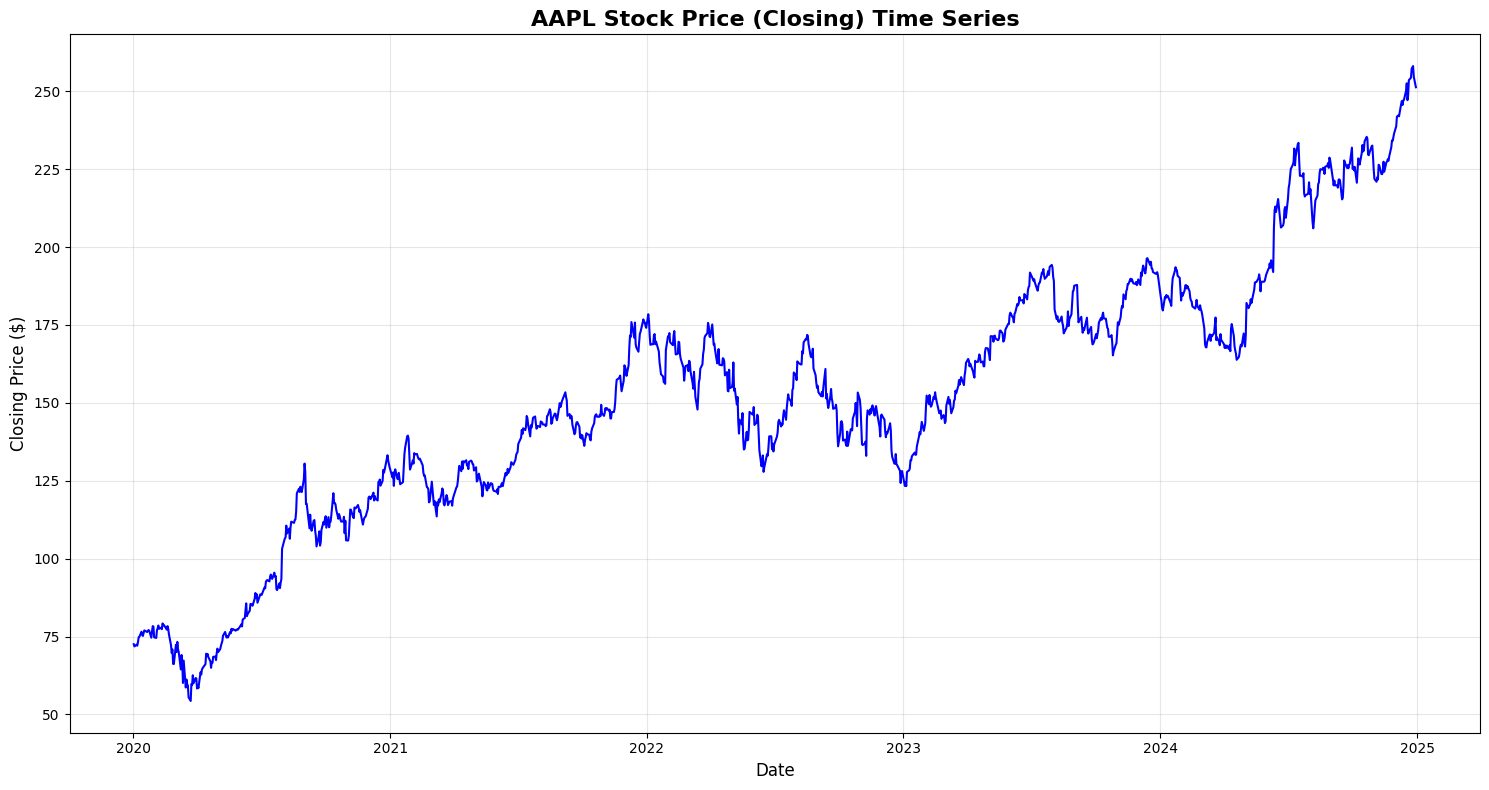

Time series length: 1257 observations
Price range: $54.32 - $258.10


In [ ]:
# Plot the closing price time series
plt.figure(figsize=(15, 8))
plt.plot(data.index, data['Close'], linewidth=1.5, color='blue')
plt.title(f'{ticker} Stock Price (Closing) Time Series', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create time series object for forecasting
ts = data['Close'].astype('float64')
print(f"Time series length: {len(ts)} observations")
print(f"Price range: ${ts.min():.2f} - ${ts.max():.2f}")


## Step 5: Baseline Level - Simple Exponential Smoothing

**Requirement:** Use one forecasting technique and forecast next 63 business days


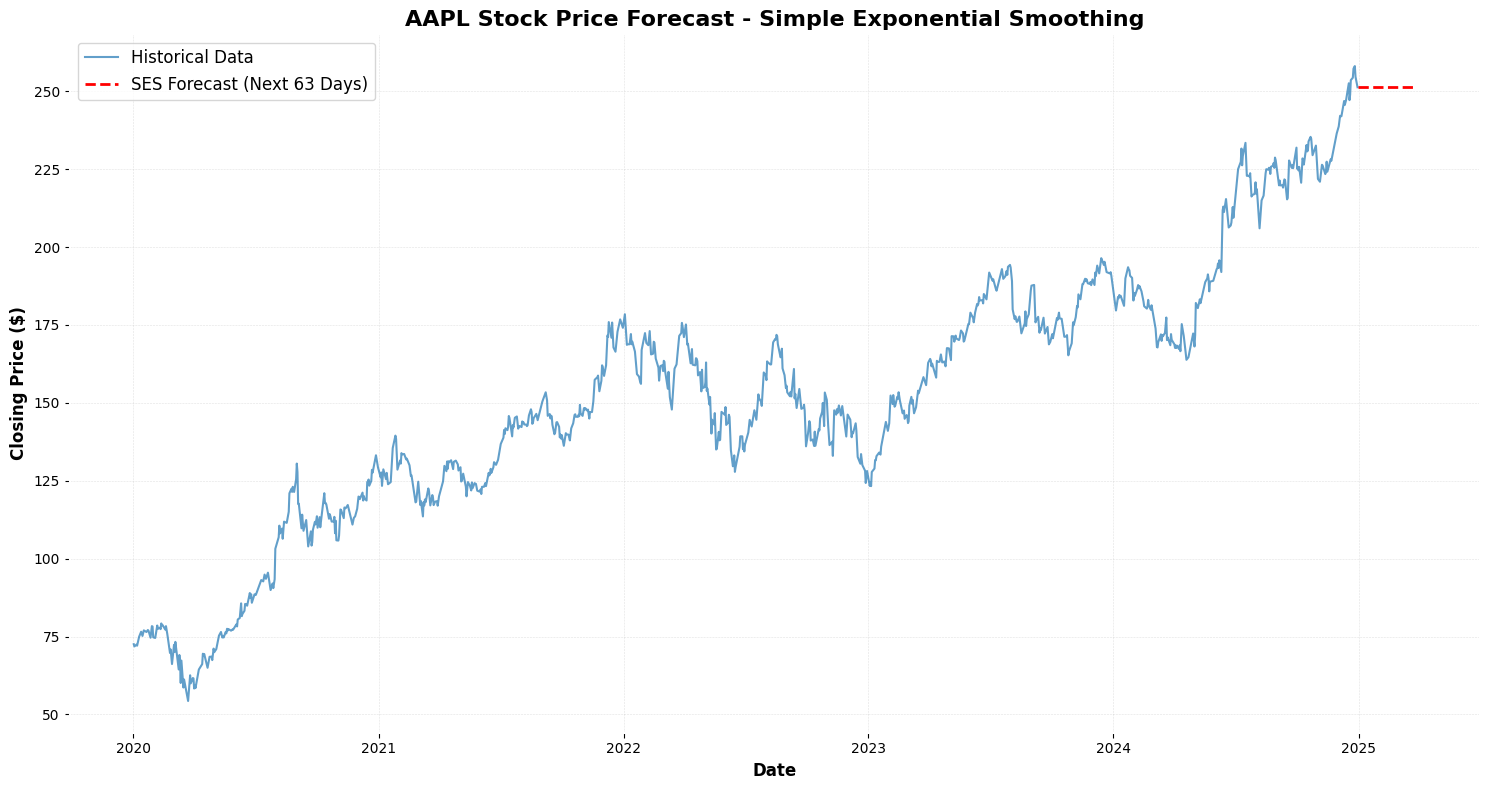


Simple Exponential Smoothing Forecast (Next 63 Business Days):


2024-12-31    251.35376
2025-01-01    251.35376
2025-01-02    251.35376
2025-01-03    251.35376
2025-01-06    251.35376
2025-01-07    251.35376
2025-01-08    251.35376
2025-01-09    251.35376
2025-01-10    251.35376
2025-01-13    251.35376
Freq: B, Name: SES_Forecast, dtype: float64


Forecast range: $251.35 - $251.35


In [ ]:
# Fit Simple Exponential Smoothing model
model_ses = SimpleExpSmoothing(ts, initialization_method="estimated").fit()

# Forecast next 63 business days
predictions_ses = model_ses.forecast(63)

# Create future index for next 63 business days
future_index = pd.date_range(
    start=ts.index[-1] + pd.offsets.BDay(1),
    periods=63,
    freq='B'
)

# Create forecast series with proper index
forecast_ses = pd.Series(predictions_ses.values, index=future_index, name='SES_Forecast')

# Plot results
plt.figure(figsize=(15, 8))
plt.plot(ts.index, ts.values, label='Historical Data', alpha=0.7, linewidth=1.5)
plt.plot(forecast_ses.index, forecast_ses.values, label='SES Forecast (Next 63 Days)', 
         color='red', linewidth=2, linestyle='--')
plt.title(f'{ticker} Stock Price Forecast - Simple Exponential Smoothing', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display forecast values
print("\nSimple Exponential Smoothing Forecast (Next 63 Business Days):")
display(forecast_ses.head(10))
print(f"\nForecast range: ${forecast_ses.min():.2f} - ${forecast_ses.max():.2f}")


## Step 6: Save Baseline Forecast to CSV


In [ ]:
# Create DataFrame for CSV export
baseline_forecast = pd.DataFrame({
    'Date': forecast_ses.index,
    'SES_Forecast': forecast_ses.values
})

# Ensure data directory exists
os.makedirs('./data', exist_ok=True)

# Save to CSV
baseline_forecast.to_csv('./data/forecast_basic.csv', index=False)
print("✅ Baseline forecast saved to './data/forecast_basic.csv'")
print(f"File contains {len(baseline_forecast)} forecasted values")

# Display first few rows
display(baseline_forecast.head())


✅ Baseline forecast saved to './data/forecast_basic.csv'
File contains 63 forecasted values


,Date,SES_Forecast
0,2024-12-31,251.35376
1,2025-01-01,251.35376
2,2025-01-02,251.35376
3,2025-01-03,251.35376
4,2025-01-06,251.35376


## Step 7: Intermediate Level - Multiple Forecasting Methods

**Requirement:** Apply at least two different forecasting models (ARIMA and Prophet)


### 7.1 ARIMA Model


In [ ]:
# Fit ARIMA model
model_arima = ARIMA(ts, order=(1, 1, 1)).fit()
predictions_arima = model_arima.forecast(steps=63)

# Create forecast series
forecast_arima = pd.Series(predictions_arima.values, index=future_index, name='ARIMA_Forecast')

print("ARIMA Model Summary:")
print(f"AIC: {model_arima.aic:.2f}")
print(f"BIC: {model_arima.bic:.2f}")
print(f"Log Likelihood: {model_arima.llf:.2f}")


ARIMA Model Summary:
AIC: 6026.09
BIC: 6041.50
Log Likelihood: -3010.04


### 7.2 Prophet Model


In [ ]:
# Prepare data for Prophet
df_prophet = ts.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

# Initialize Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Fit Prophet model
prophet_model.fit(df_prophet)

# Create future DataFrame for the next 63 business days
future_prophet = prophet_model.make_future_dataframe(periods=63, freq='B')

# Forecast
forecast_prophet = prophet_model.predict(future_prophet)

# Extract only the future forecast values
future_forecast = forecast_prophet.tail(63).copy()
forecast_prophet_series = pd.Series(
    future_forecast['yhat'].values, 
    index=pd.to_datetime(future_forecast['ds']), 
    name='Prophet_Forecast'
)

print("Prophet model fitted successfully")
print(f"Forecast range: ${forecast_prophet_series.min():.2f} - ${forecast_prophet_series.max():.2f}")


Prophet model fitted successfully
Forecast range: $239.62 - $252.15


### 7.3 Compare Intermediate Level Forecasts


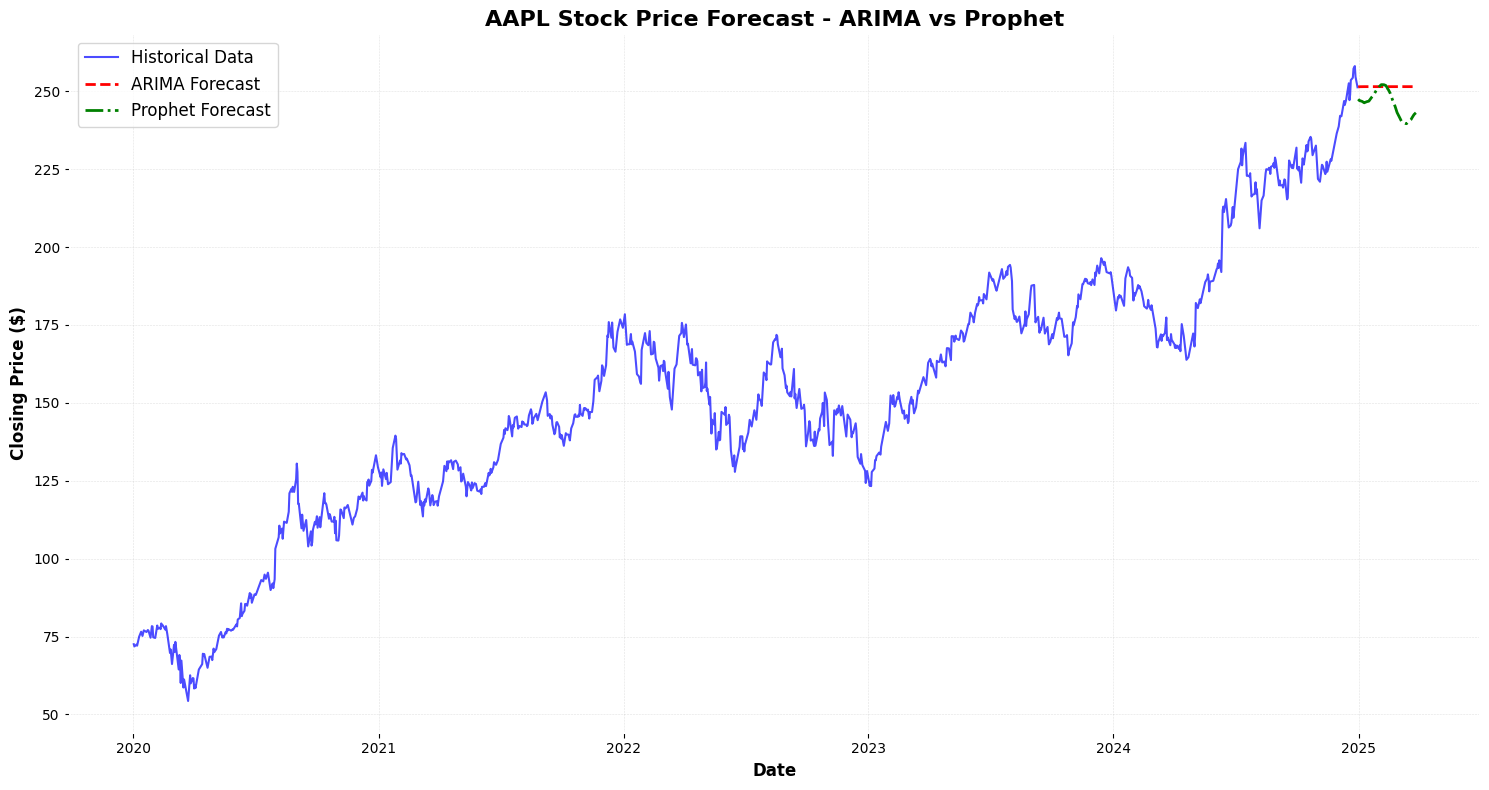


Forecast Comparison (First 10 days):


,ARIMA_Forecast,Prophet_Forecast
2024-12-31,251.394950,247.470247
2025-01-01,251.442981,247.234863
2025-01-02,251.469476,246.994230
2025-01-03,251.484091,246.971636
2025-01-06,251.492153,246.751710
2025-01-07,251.496600,246.607346
2025-01-08,251.499053,246.454384
2025-01-09,251.500407,246.319351
2025-01-10,251.501153,246.424014
2025-01-13,251.501565,246.695573



Forecast Statistics:
ARIMA - Mean: $251.50, Std: $0.02
Prophet - Mean: $246.13, Std: $4.11


In [ ]:
# Plot comparison of both methods
plt.figure(figsize=(15, 8))
plt.plot(ts.index, ts.values, label='Historical Data', alpha=0.7, linewidth=1.5, color='blue')
plt.plot(forecast_arima.index, forecast_arima.values, label='ARIMA Forecast', 
         color='red', linewidth=2, linestyle='--')
plt.plot(forecast_prophet_series.index, forecast_prophet_series.values, label='Prophet Forecast', 
         color='green', linewidth=2, linestyle='-.')
plt.title(f'{ticker} Stock Price Forecast - ARIMA vs Prophet', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display forecast comparison table
comparison_df = pd.DataFrame({
    'ARIMA_Forecast': forecast_arima.values,
    'Prophet_Forecast': forecast_prophet_series.values
}, index=future_index)

print("\nForecast Comparison (First 10 days):")
display(comparison_df.head(10))

print("\nForecast Statistics:")
print(f"ARIMA - Mean: ${forecast_arima.mean():.2f}, Std: ${forecast_arima.std():.2f}")
print(f"Prophet - Mean: ${forecast_prophet_series.mean():.2f}, Std: ${forecast_prophet_series.std():.2f}")


## Step 8: Save Intermediate Forecast to CSV


In [ ]:
# Create comprehensive DataFrame for intermediate level
intermediate_forecast = pd.DataFrame({
    'Date': future_index,
    'ARIMA_Forecast': forecast_arima.values,
    'Prophet_Forecast': forecast_prophet_series.values
})

# Save to CSV
intermediate_forecast.to_csv('./data/forecast_intermediate.csv', index=False)
print("✅ Intermediate forecast saved to './data/forecast_intermediate.csv'")
print(f"File contains {len(intermediate_forecast)} forecasted values for each method")

# Display first few rows
display(intermediate_forecast.head())


✅ Intermediate forecast saved to './data/forecast_intermediate.csv'
File contains 63 forecasted values for each method


,Date,ARIMA_Forecast,Prophet_Forecast
0,2024-12-31,251.394950,247.470247
1,2025-01-01,251.442981,247.234863
2,2025-01-02,251.469476,246.994230
3,2025-01-03,251.484091,246.971636
4,2025-01-06,251.492153,246.751710


## Step 9: Advanced Level - LSTM with Hyperparameter Tuning

**Requirement:** Apply at least three forecasting models including LSTM with hyperparameter tuning


### 9.1 LSTM Data Preparation


In [ ]:
# LSTM hyperparameter configurations
window_size = 12
scaler = MinMaxScaler()
scaled_ts = scaler.fit_transform(ts.values.reshape(-1, 1))

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, 0])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_ts, window_size)
X = X.reshape((X.shape[0], window_size, 1))

print(f"LSTM training data shape: X={X.shape}, y={y.shape}")
print(f"Scaled data range: {scaled_ts.min():.4f} to {scaled_ts.max():.4f}")


LSTM training data shape: X=(1245, 12, 1), y=(1245,)
Scaled data range: 0.0000 to 1.0000


### 9.2 LSTM Hyperparameter Tuning


In [ ]:
# Define hyperparameter configurations
hyperparams = [
    {'units': 32, 'lr': 0.01, 'epochs': 40, 'batch': 16, 'name': 'LSTM_32_0.01'},
    {'units': 64, 'lr': 0.005, 'epochs': 50, 'batch': 32, 'name': 'LSTM_64_0.005'},
    {'units': 100, 'lr': 0.001, 'epochs': 60, 'batch': 16, 'name': 'LSTM_100_0.001'}
]

lstm_results = {}

print("Training LSTM models with different hyperparameters...")
for i, params in enumerate(hyperparams):
    print(f"\nTraining model {i+1}/3: {params['name']}")
    
    # Build LSTM model
    model = Sequential([
        LSTM(params['units'], activation='tanh', input_shape=(window_size, 1)),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='mse')
    
    # Train model
    history = model.fit(X, y, epochs=params['epochs'], batch_size=params['batch'], 
                       validation_split=0.1, verbose=0)
    
    # Forecast next 63 business days
    last_sequence = scaled_ts[-window_size:].reshape(1, window_size, 1)
    predictions_scaled = []
    
    for _ in range(63):
        pred = model.predict(last_sequence, verbose=0)
        predictions_scaled.append(pred[0, 0])
        last_sequence = np.concatenate([last_sequence[:, 1:, :], pred.reshape(1, 1, 1)], axis=1)
    
    # Inverse transform predictions
    predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
    
    # Store results
    lstm_results[params['name']] = predictions
    
    print(f"Final training loss: {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

print("\n✅ All LSTM models trained successfully!")


Training LSTM models with different hyperparameters...

Training model 1/3: LSTM_32_0.01
Final training loss: 0.000189
Final validation loss: 0.000828

Training model 2/3: LSTM_64_0.005
Final training loss: 0.000240
Final validation loss: 0.000496

Training model 3/3: LSTM_100_0.001
Final training loss: 0.000210
Final validation loss: 0.000646

✅ All LSTM models trained successfully!


### 9.3 Create Advanced Level Forecast DataFrame


In [ ]:
# Create DataFrame with all forecasting methods
advanced_forecast = pd.DataFrame({
    'Date': future_index,
    'ARIMA_Forecast': forecast_arima.values,
    'Prophet_Forecast': forecast_prophet_series.values
})

# Add LSTM forecasts
for name, predictions in lstm_results.items():
    advanced_forecast[name] = predictions

print("Advanced Level Forecast DataFrame:")
print(f"Shape: {advanced_forecast.shape}")
print(f"Columns: {list(advanced_forecast.columns)}")

# Display first few rows
display(advanced_forecast.head())


Advanced Level Forecast DataFrame:
Shape: (63, 6)
Columns: ['Date', 'ARIMA_Forecast', 'Prophet_Forecast', 'LSTM_32_0.01', 'LSTM_64_0.005', 'LSTM_100_0.001']


,Date,ARIMA_Forecast,Prophet_Forecast,LSTM_32_0.01,LSTM_64_0.005,LSTM_100_0.001
0,2024-12-31,251.394950,247.470247,245.189941,256.139008,247.281815
1,2025-01-01,251.442981,247.234863,239.017654,257.716949,243.083954
2,2025-01-02,251.469476,246.994230,233.040512,260.281219,239.038330
3,2025-01-03,251.484091,246.971636,227.343323,263.264984,235.322739
4,2025-01-06,251.492153,246.751710,221.919128,266.370972,231.949982


### 9.4 Visualize All Advanced Level Forecasts


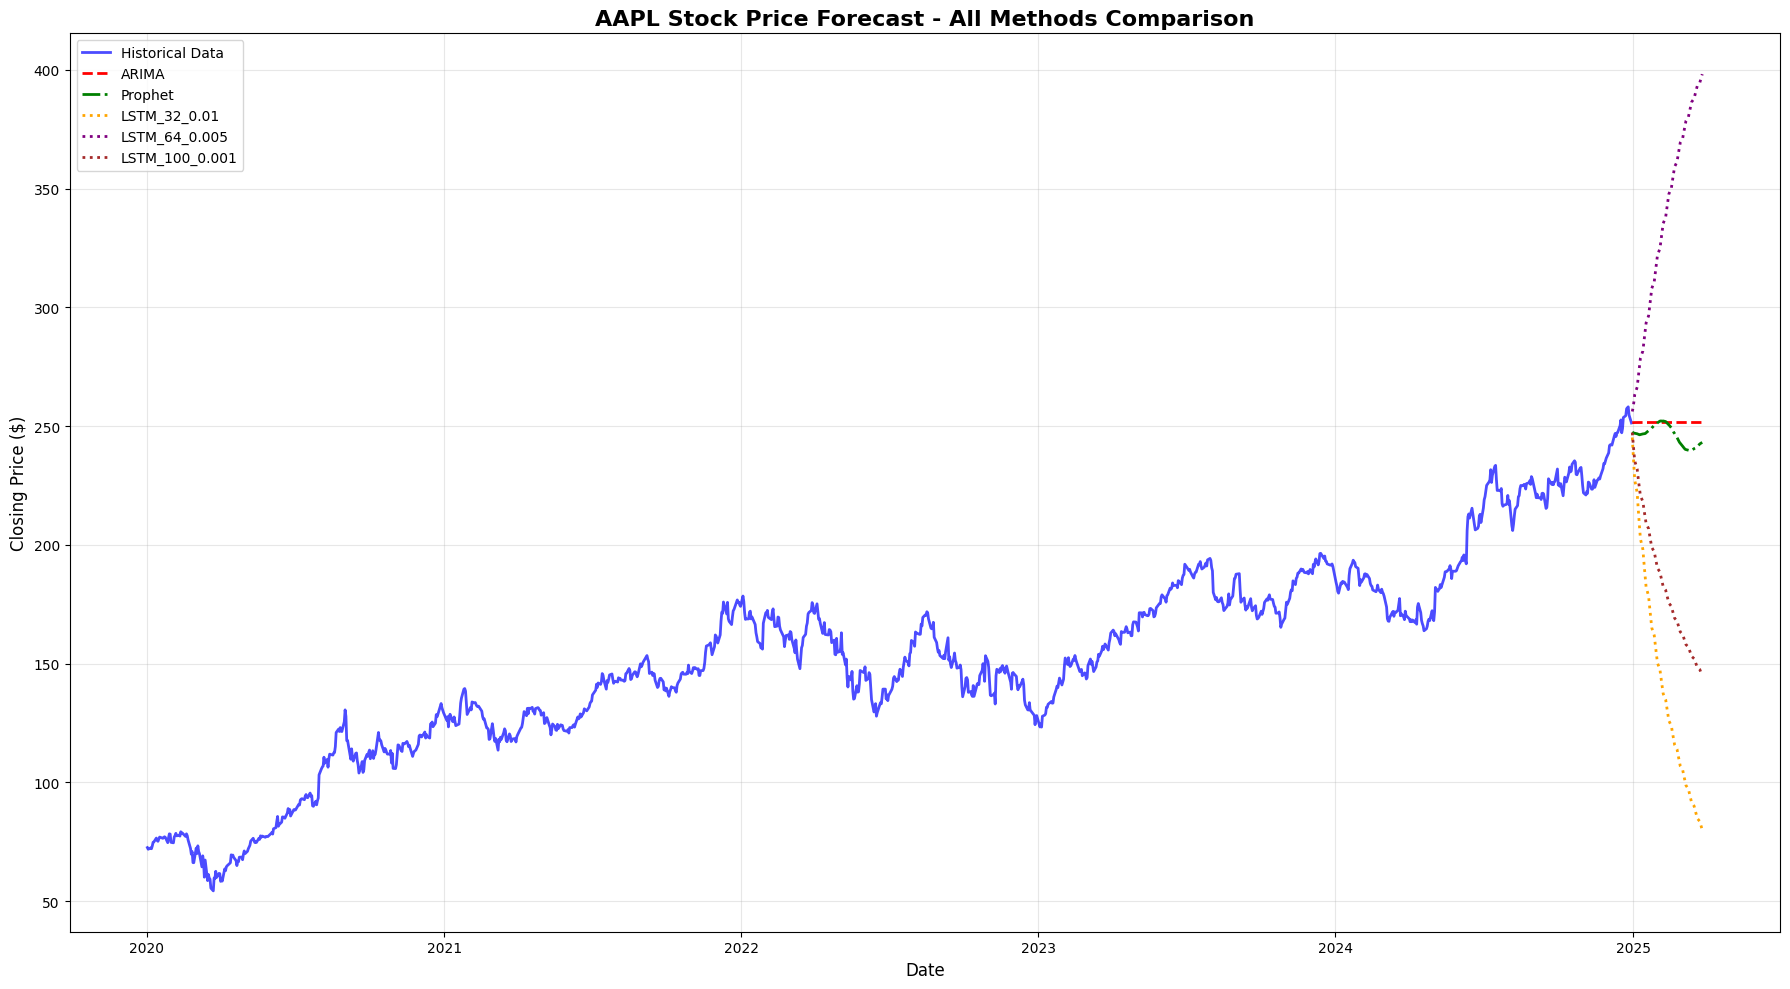


Forecast Statistics Summary:
ARIMA_Forecast      : Mean=$251.50, Std=$0.02, Min=$251.39, Max=$251.50
Prophet_Forecast    : Mean=$246.13, Std=$4.11, Min=$239.62, Max=$252.15
LSTM_32_0.01        : Mean=$140.50, Std=$46.63, Min=$79.95, Max=$245.19
LSTM_64_0.005       : Mean=$336.93, Std=$43.71, Min=$256.14, Max=$398.14
LSTM_100_0.001      : Mean=$183.50, Std=$28.41, Min=$144.90, Max=$247.28


In [ ]:
# Plot all forecasting methods
plt.figure(figsize=(18, 10))
plt.plot(ts.index, ts.values, label='Historical Data', alpha=0.7, linewidth=2, color='blue')

# Plot ARIMA and Prophet
plt.plot(forecast_arima.index, forecast_arima.values, label='ARIMA', 
         color='red', linewidth=2, linestyle='--')
plt.plot(forecast_prophet_series.index, forecast_prophet_series.values, label='Prophet', 
         color='green', linewidth=2, linestyle='-.')

# Plot LSTM variants
colors = ['orange', 'purple', 'brown']
for i, (name, predictions) in enumerate(lstm_results.items()):
    plt.plot(future_index, predictions, label=name, 
             color=colors[i], linewidth=2, linestyle=':')

plt.title(f'{ticker} Stock Price Forecast - All Methods Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display forecast statistics
print("\nForecast Statistics Summary:")
for col in advanced_forecast.columns[1:]:  # Skip Date column
    values = advanced_forecast[col]
    print(f"{col:20s}: Mean=${values.mean():.2f}, Std=${values.std():.2f}, Min=${values.min():.2f}, Max=${values.max():.2f}")


## Step 10: Save Advanced Forecast to CSV


In [ ]:
# Save advanced forecast to CSV
advanced_forecast.to_csv('./data/forecast_advanced.csv', index=False)
print("✅ Advanced forecast saved to './data/forecast_advanced.csv'")
print(f"File contains {len(advanced_forecast)} forecasted values for {len(advanced_forecast.columns)-1} methods")

# Display summary
print("\nAdvanced Forecast Summary:")
display(advanced_forecast.describe())


✅ Advanced forecast saved to './data/forecast_advanced.csv'
File contains 63 forecasted values for 5 methods

Advanced Forecast Summary:


,Date,ARIMA_Forecast,Prophet_Forecast,LSTM_32_0.01,LSTM_64_0.005,LSTM_100_0.001
count,63,63.000000,63.000000,63.000000,63.000000,63.000000
mean,2025-02-12 00:00:00,251.498279,246.133282,140.499802,336.926300,183.499588
min,2024-12-31 00:00:00,251.394950,239.615858,79.947281,256.139008,144.895035
25%,2025-01-21 12:00:00,251.502060,242.593966,101.057781,300.758408,159.556389
50%,2025-02-12 00:00:00,251.502071,246.791949,130.312531,342.909210,178.146637
75%,2025-03-05 12:00:00,251.502071,249.229727,173.263634,375.871475,203.762924
max,2025-03-27 00:00:00,251.502071,252.150075,245.189941,398.144714,247.281815
std,NaN,0.015856,4.106567,46.626965,43.707523,28.410425


## Step 11: GPU Usage Check (Advanced Level)

Check if GPU is available for LSTM training (as per advanced requirements)


In [ ]:
# Check GPU availability
gpu_count = len(tf.config.list_physical_devices('GPU'))
print(f"Number of GPUs available: {gpu_count}")

if gpu_count > 0:
    print("✅ GPU is available for LSTM training")
    print("GPU Details:")
    for i, gpu in enumerate(tf.config.list_physical_devices('GPU')):
        print(f"  GPU {i}: {gpu}")
    
    # Demonstrate GPU usage for one LSTM model
    print("\nDemonstrating GPU usage for LSTM training...")
    
    with tf.device('/GPU:0'):
        # Quick LSTM model for demonstration
        gpu_model = Sequential([
            LSTM(50, activation='tanh', input_shape=(window_size, 1)),
            Dense(1)
        ])
        gpu_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        
        # Train for a few epochs to demonstrate GPU usage
        gpu_history = gpu_model.fit(X, y, epochs=5, batch_size=16, verbose=0)
        
    print(f"GPU training completed. Final loss: {gpu_history.history['loss'][-1]:.6f}")
    print("\nNote: GPU usage can significantly reduce training time for larger models and datasets.")
    
else:
    print("❌ No GPU available. LSTM models were trained on CPU.")
    print("To use GPU for LSTM training:")
    print("1. Install compatible NVIDIA drivers")
    print("2. Install CUDA Toolkit")
    print("3. Install cuDNN")
    print("4. Install TensorFlow with GPU support")


Number of GPUs available: 0
❌ No GPU available. LSTM models were trained on CPU.
To use GPU for LSTM training:
1. Install compatible NVIDIA drivers
2. Install CUDA Toolkit
3. Install cuDNN
4. Install TensorFlow with GPU support


## Step 12: Summary and Next Steps


In [ ]:
print("🎉 Lab Implementation Complete!")
print("\n" + "="*60)
print("SUMMARY OF DELIVERABLES")
print("="*60)

print("\n📊 FORECAST FILES CREATED:")
print("1. ./data/forecast_basic.csv - Simple Exponential Smoothing")
print("2. ./data/forecast_intermediate.csv - ARIMA + Prophet comparison")
print("3. ./data/forecast_advanced.csv - All methods including LSTM variants")

print("\n📈 FORECASTING METHODS IMPLEMENTED:")
print("• Simple Exponential Smoothing (Baseline)")
print("• ARIMA (1,1,1) (Intermediate)")
print("• Prophet with seasonality (Intermediate)")
print("• LSTM with 3 hyperparameter configurations (Advanced)")

print("\n📅 FORECAST HORIZON:")
print(f"• Next 63 business days starting from {future_index[0].strftime('%Y-%m-%d')}")
print(f"• Ending on {future_index[-1].strftime('%Y-%m-%d')}")

print("\n🎯 NEXT STEPS FOR POWER BI:")
print("1. Import the CSV files into Power BI")
print("2. Create line charts for each forecast method")
print("3. Build comparative dashboards")
print("4. Add summary tables and metrics")

print("\n📹 VIDEO DEMONSTRATION:")
print("Create a 4-minute video showing:")
print("• The forecasting process")
print("• Power BI dashboard creation")
print("• Results interpretation")

print("\n" + "="*60)
print("Lab implementation completed successfully! 🚀")


🎉 Lab Implementation Complete!

SUMMARY OF DELIVERABLES

📊 FORECAST FILES CREATED:
1. ./data/forecast_basic.csv - Simple Exponential Smoothing
2. ./data/forecast_intermediate.csv - ARIMA + Prophet comparison
3. ./data/forecast_advanced.csv - All methods including LSTM variants

📈 FORECASTING METHODS IMPLEMENTED:
• Simple Exponential Smoothing (Baseline)
• ARIMA (1,1,1) (Intermediate)
• Prophet with seasonality (Intermediate)
• LSTM with 3 hyperparameter configurations (Advanced)

📅 FORECAST HORIZON:
• Next 63 business days starting from 2024-12-31
• Ending on 2025-03-27

🎯 NEXT STEPS FOR POWER BI:
1. Import the CSV files into Power BI
2. Create line charts for each forecast method
3. Build comparative dashboards
4. Add summary tables and metrics

📹 VIDEO DEMONSTRATION:
Create a 4-minute video showing:
• The forecasting process
• Power BI dashboard creation
• Results interpretation

Lab implementation completed successfully! 🚀
